# 　过拟合
发生过拟合的原因，主要有以下两个
- 模型拥有大量参数、表现力强
- 训练数据少

In [ ]:

import sys, os
sys.path.append(os.pardir)
import numpy as np
from typing import Dict, List
import matplotlib.pyplot as plt

from libs.network import NeuralNet
from libs.trainer import Trainer
from libs.util import smooth_curve


# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [2]:
# 加载数据集
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)


# 仅使用前300个训练样本
x_train, t_train = x_train[:300], t_train[:300]
# x_test, t_test = x_test[:100], t_test[:100]

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)


save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
(300, 784)
(300, 10)
(10000, 784)
(10000, 10)


In [3]:
def start_train(optimizer: str='sgd', hidden_size_list: List[int]=[100, 100, 100, 100, 100, 100], 
                epochs: int=250, mini_batch_size: int=100, activation: str="relu", weight_scale: str|float="he", 
                weight_decay_lambda: float=0.0, use_dropout: bool=False, dropout_ration: float=0.5, use_batchnorm=False
    ) -> List[float]:
    trainer = Trainer(
        network=NeuralNet(input_size=x_train.shape[1], hidden_size_list=hidden_size_list, 
                              output_size=t_train.shape[1], activation=activation, weight_scale=weight_scale, 
                              weight_decay_lambda=weight_decay_lambda, 
                              use_dropout=use_dropout, dropout_ration=dropout_ration, use_batchnorm=use_batchnorm),
        x_train=x_train,
        t_train=t_train,
        x_test=x_test,
        t_test=t_test,
        optimizer=optimizer,
        # optimizer_param=optimizer_param,
        epochs=epochs,
        mini_batch_size=mini_batch_size,
        verbose=True
    )
    trainer.train()
    return trainer.train_loss_list, trainer.train_acc_list, trainer.test_acc_list

网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:100), b3(100)
	【激活层】: Relu3
	【全连接层】: Affine4, W4(100:100), b4(100)
	【激活层】: Relu4
	【全连接层】: Affine5, W5(100:100), b5(100)
	【激活层】: Relu5
	【全连接层】: Affine6, W6(100:100), b6(100)
	【激活层】: Relu6
	【全连接层】: Affine7, W7(100:10), b7(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:258.83272701946987, train acc:0.03666666666666667, test acc:0.056666666666666664
epoch:2, loss:230.8217205227471, train acc:0.09333333333333334, test acc:0.09333333333333334
epoch:3, loss:225.17311015450593, train acc:0.14333333333333334, test acc:0.12666666666666668
epoch:4, loss:213.2290728906446, train acc:0.19333333333333333, test acc:0.13666666666666666
epoch:5, loss:209.44876609110082, train acc:0.26, test acc:0.19
epoch:6, loss:200.14551643610343, train acc:0.3333333333333333, test acc:0.21333333333333335
epoch:7, loss:192.63403446220218, train acc:0.37666666666666665, test acc:0.25666

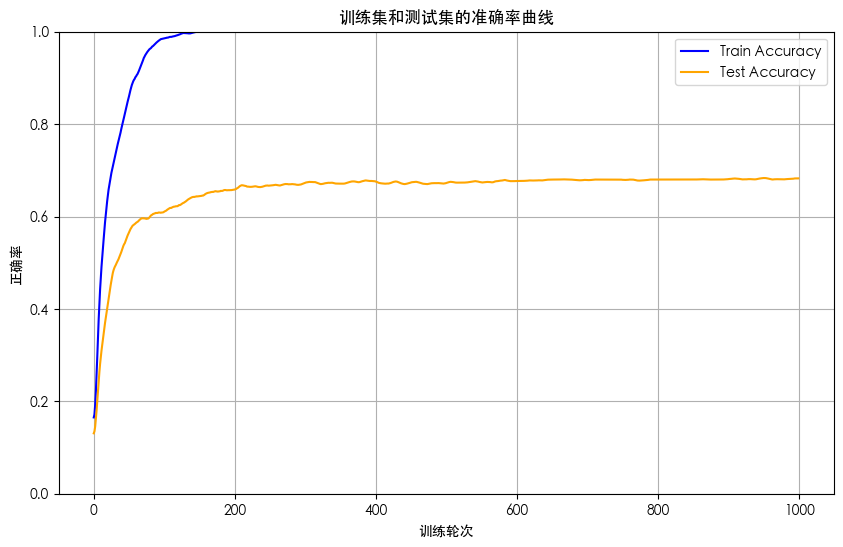

In [4]:

_, train_acc_list, test_acc_list = start_train(epochs=1000)

# 绘制训练集和测试集的准确率曲线
plt.figure(figsize=(10, 6))
plt.plot(smooth_curve(train_acc_list), label='Train Accuracy', color='blue')
plt.plot(smooth_curve(test_acc_list), label='Test Accuracy', color='orange')
plt.title('训练集和测试集的准确率曲线')
plt.xlabel('训练轮次')
plt.ylabel('正确率')
plt.legend()
plt.grid()
plt.ylim(0, 1.0)
plt.show()

## 通过权值衰减抑制过拟合

网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:100), b3(100)
	【激活层】: Relu3
	【全连接层】: Affine4, W4(100:100), b4(100)
	【激活层】: Relu4
	【全连接层】: Affine5, W5(100:100), b5(100)
	【激活层】: Relu5
	【全连接层】: Affine6, W6(100:100), b6(100)
	【激活层】: Relu6
	【全连接层】: Affine7, W7(100:10), b7(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:364.5137819834796, train acc:0.09, test acc:0.07333333333333333
epoch:2, loss:359.2308783369431, train acc:0.11666666666666667, test acc:0.08
epoch:3, loss:344.63519503496923, train acc:0.19666666666666666, test acc:0.10666666666666667
epoch:4, loss:333.86402861185275, train acc:0.25333333333333335, test acc:0.15
epoch:5, loss:331.5036686543427, train acc:0.2866666666666667, test acc:0.16666666666666666
epoch:6, loss:338.73211136444297, train acc:0.35, test acc:0.19
epoch:7, loss:327.77207561026285, train acc:0.3566666666666667, test acc:0.17333333333333334
epoch:8, loss:324.3714771406617, tr

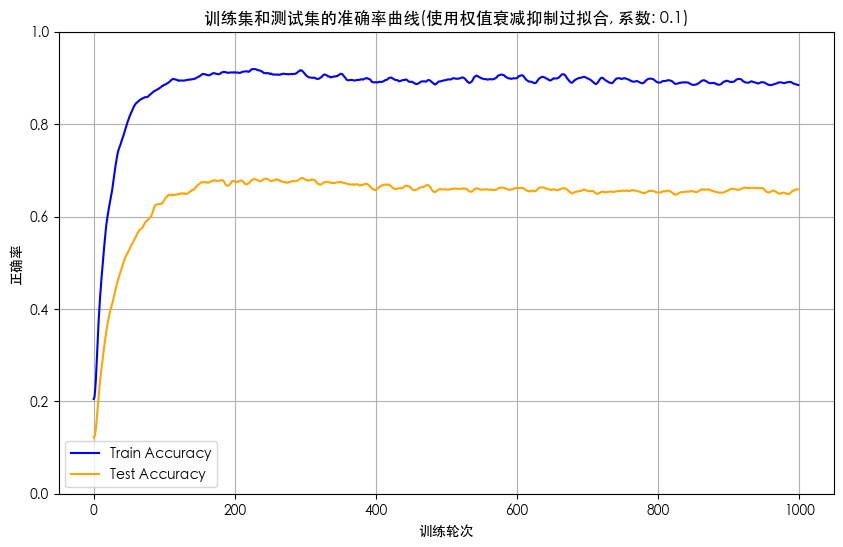

In [5]:

weight_decay_lambda = 0.1  # 权重衰减系数
_, train_acc_list, test_acc_list = start_train(epochs=1000, weight_decay_lambda=weight_decay_lambda)

# 绘制训练集和测试集的准确率曲线
plt.figure(figsize=(10, 6))
plt.plot(smooth_curve(train_acc_list), label='Train Accuracy', color='blue')
plt.plot(smooth_curve(test_acc_list), label='Test Accuracy', color='orange')
plt.title(f'训练集和测试集的准确率曲线(使用权值衰减抑制过拟合, 系数: {weight_decay_lambda})')
plt.xlabel('训练轮次')
plt.ylabel('正确率')
plt.legend()
plt.grid()
plt.ylim(0, 1.0)
plt.show()

## 通过 Dropout 抑制过拟合

网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【Dropout层】比率: 0.2
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【Dropout层】比率: 0.2
	【全连接层】: Affine3, W3(100:100), b3(100)
	【激活层】: Relu3
	【Dropout层】比率: 0.2
	【全连接层】: Affine4, W4(100:100), b4(100)
	【激活层】: Relu4
	【Dropout层】比率: 0.2
	【全连接层】: Affine5, W5(100:100), b5(100)
	【激活层】: Relu5
	【Dropout层】比率: 0.2
	【全连接层】: Affine6, W6(100:100), b6(100)
	【激活层】: Relu6
	【Dropout层】比率: 0.2
	【全连接层】: Affine7, W7(100:10), b7(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:313.60720182777084, train acc:0.08666666666666667, test acc:0.12333333333333334
epoch:2, loss:285.1246205217042, train acc:0.09333333333333334, test acc:0.12666666666666668
epoch:3, loss:271.5935676904759, train acc:0.09333333333333334, test acc:0.13
epoch:4, loss:259.9350632048356, train acc:0.09666666666666666, test acc:0.15
epoch:5, loss:260.2923044592959, train acc:0.1, test acc:0.14
epoch:6, loss:261.5584401092275, train acc:0.10666666666666667, test acc:0.13666666666666666
e

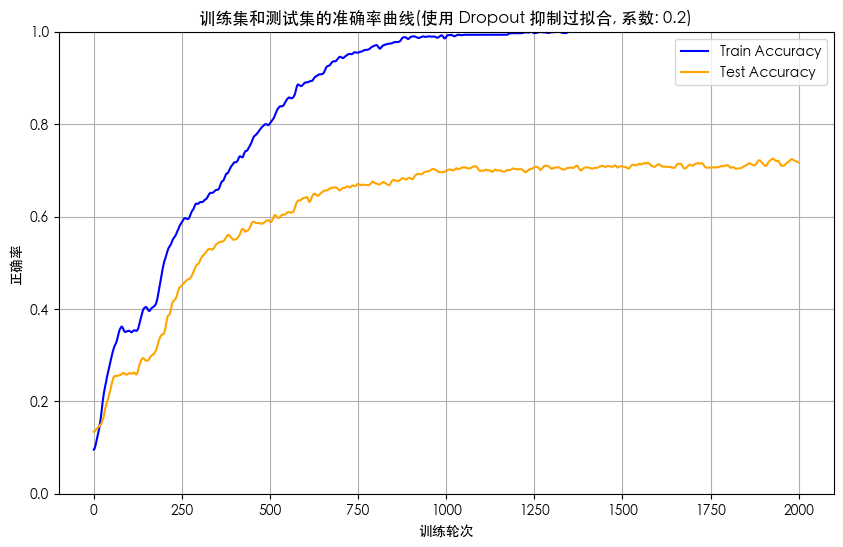

In [6]:

dropout_ration = 0.2  # Dropout比率
_, train_acc_list, test_acc_list = start_train(epochs=2000, use_dropout=True, dropout_ration=dropout_ration)

# 绘制训练集和测试集的准确率曲线
plt.figure(figsize=(10, 6))
plt.plot(smooth_curve(train_acc_list), label='Train Accuracy', color='blue')
plt.plot(smooth_curve(test_acc_list), label='Test Accuracy', color='orange')
plt.title(f'训练集和测试集的准确率曲线(使用 Dropout 抑制过拟合, 系数: {dropout_ration})')
plt.xlabel('训练轮次')
plt.ylabel('正确率')
plt.legend()
plt.grid()
plt.ylim(0, 1.0)
plt.show()

网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【Dropout层】比率: 0.2
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【Dropout层】比率: 0.2
	【全连接层】: Affine3, W3(100:100), b3(100)
	【激活层】: Relu3
	【Dropout层】比率: 0.2
	【全连接层】: Affine4, W4(100:100), b4(100)
	【激活层】: Relu4
	【Dropout层】比率: 0.2
	【全连接层】: Affine5, W5(100:100), b5(100)
	【激活层】: Relu5
	【Dropout层】比率: 0.2
	【全连接层】: Affine6, W6(100:100), b6(100)
	【激活层】: Relu6
	【Dropout层】比率: 0.2
	【全连接层】: Affine7, W7(100:10), b7(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:407.2122849699941, train acc:0.11333333333333333, test acc:0.11
epoch:2, loss:392.13093901746936, train acc:0.11, test acc:0.11
epoch:3, loss:369.0846437211516, train acc:0.11, test acc:0.10666666666666667
epoch:4, loss:369.80887104852974, train acc:0.11, test acc:0.11666666666666667
epoch:5, loss:368.4133282129468, train acc:0.10666666666666667, test acc:0.11666666666666667
epoch:6, loss:369.62592869407064, train acc:0.11, test acc:0.12
epoch:7, loss:351.2514191763397, train acc:

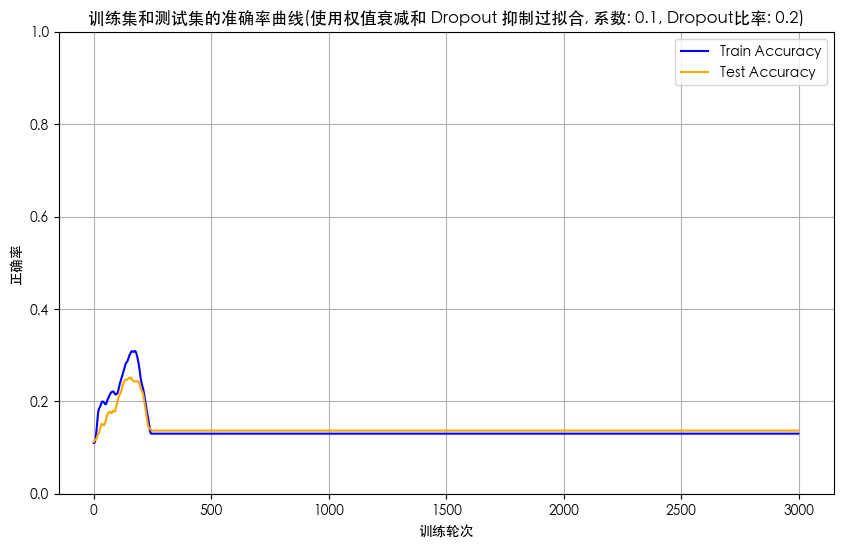

In [7]:
weight_decay_lambda = 0.1  # 权重衰减系数
dropout_ration = 0.2  # Dropout比率
_, train_acc_list, test_acc_list = start_train(epochs=3000, weight_decay_lambda=weight_decay_lambda, use_dropout=True, dropout_ration=dropout_ration)

# 绘制训练集和测试集的准确率曲线
plt.figure(figsize=(10, 6))
plt.plot(smooth_curve(train_acc_list), label='Train Accuracy', color='blue')
plt.plot(smooth_curve(test_acc_list), label='Test Accuracy', color='orange')
plt.title(f'训练集和测试集的准确率曲线(使用权值衰减和 Dropout 抑制过拟合, 系数: {weight_decay_lambda}, Dropout比率: {dropout_ration})')
plt.xlabel('训练轮次')
plt.ylabel('正确率')
plt.legend()
plt.grid()
plt.ylim(0, 1.0)
plt.show()